In [88]:
from sklearn.datasets import load_breast_cancer
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score, f1_score, precision_score, recall_score, confusion_matrix, ConfusionMatrixDisplay
from sklearn.naive_bayes import GaussianNB, MultinomialNB, BernoulliNB
from sklearn.datasets import fetch_20newsgroups
from sklearn.feature_extraction.text import CountVectorizer
import matplotlib.pyplot as plt

# Modelo Guassian NB

In [89]:
datos = load_breast_cancer()

In [90]:
X = datos.data
y = datos.target

In [91]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state= 24)

In [92]:
modelo = GaussianNB()
modelo.fit(X_train, y_train)
y_pred = modelo.predict(X_test)

In [93]:
print("Accuracy del Guassian NB",
    accuracy_score(
    y_test,
    y_pred)
)

Accuracy del Guassian NB 0.9210526315789473


In [94]:
score = f1_score(y_test, y_pred)
print("F1 score: ", score)

F1 score:  0.9379310344827586


In [95]:
precision = precision_score(y_test, y_pred)
print("Precision score: ", precision)

Precision score:  0.9444444444444444


In [96]:
recall = recall_score(y_test, y_pred)
print("Recall: ", recall)

Recall:  0.9315068493150684


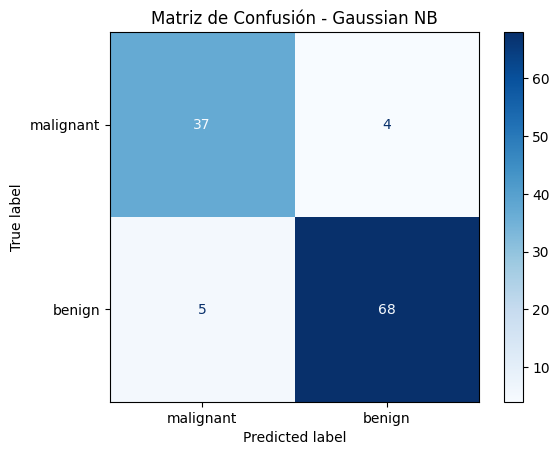

In [97]:
cm = confusion_matrix(y_test, y_pred)
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=datos.target_names)
disp.plot(cmap='Blues')
plt.title("Matriz de Confusión - Gaussian NB")
plt.show()

INTERPRETACIÓN: En base a los resultadosse obserava que este modelo tiene un rendimiento sólido, ya que la precision tiene 0.944 y recall de 0.931 entonces nos damos cuenta que hay pocos falsos positivos y falsos negativos, lo que también se observa en un F1 de 0.937 y con el accuracy de 0.921 confirma que de 114 muestras del test, aproximadamente 9 fueron clasificadas incorrectamente.


# Modelo Multinomial NB

In [98]:
categorias = [
    'sci.space',
    'rec.sport.baseball'
]

In [99]:
datos = fetch_20newsgroups(subset='train', categories=categorias)

In [100]:
vectorizador = CountVectorizer(binary=True)

In [101]:
Xm = vectorizador.fit_transform(datos.data)
ym = datos.target

In [102]:
X_trainM, X_testM, y_trainM, y_testM = train_test_split(Xm, ym, test_size= 0.3, random_state=24)

In [103]:
modeloM = MultinomialNB()
modeloM.fit(X_trainM, y_trainM)
y_predM = modeloM.predict(X_testM)

In [104]:
print("Modelo Multinomial: ",
    accuracy_score
     (y_true = y_testM, y_pred = y_predM))

Modelo Multinomial:  0.9943977591036415


In [105]:
score = f1_score(y_testM, y_predM)
print("F1 score: ", score)

F1 score:  0.9940828402366864


In [106]:
precision = precision_score(y_testM, y_predM)
print("Precision score: ", precision)

Precision score:  1.0


In [107]:
recall = recall_score(y_testM, y_predM)
print("Recall: ", recall)

Recall:  0.9882352941176471


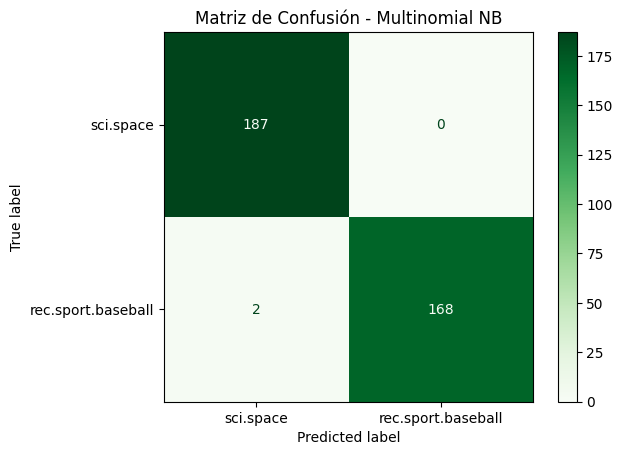

In [108]:
cm = confusion_matrix(y_testM, y_predM)
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=categorias)
disp.plot(cmap='Greens')
plt.title("Matriz de Confusión - Multinomial NB")
plt.show()

INTERPRETACIÓN: La precision en este modelo fue de 1.0, eso indica que ningún caso fue clasificado como positivo incorrectamente. En el caso de  recall de 0.988 nos da a entender que solo falló en detectar 1 o 2 casos positivos reales. El F1 de 0.994 y accuracy de 0.994 observanos que lo hace prácticamente perfecto.


# Modelo Bernoulli NB

In [109]:
modeloB = BernoulliNB()
modeloB.fit(X_trainM, y_trainM)
y_predB = modeloB.predict(X_testM)

In [110]:
print("Modelo Bernoulli NB",
accuracy_score(y_true = y_testM, y_pred = y_predB))

Modelo Bernoulli NB 0.9159663865546218


In [111]:
score = f1_score(y_testM, y_predB)
print("F1 score: ", score)

F1 score:  0.9038461538461539


In [112]:
precision = precision_score(y_testM, y_predB)
print("Precision score: ", precision)

Precision score:  0.9929577464788732


In [113]:
recall = recall_score(y_testM, y_predB)
print("Recall: ", recall)

Recall:  0.8294117647058824


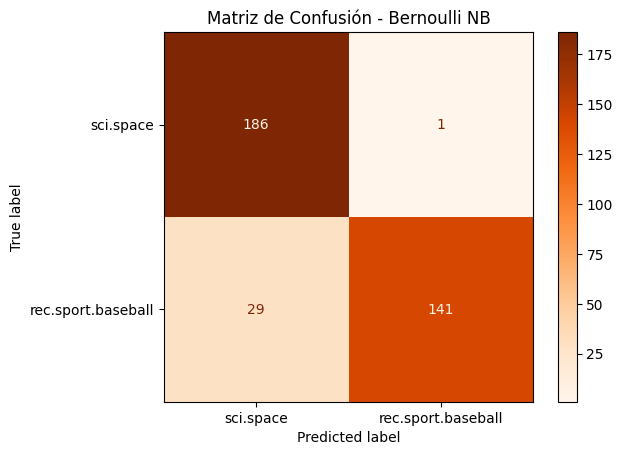

In [114]:
cm = confusion_matrix(y_testM, y_predB)
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=categorias)
disp.plot(cmap='Oranges')
plt.title("Matriz de Confusión - Bernoulli NB")
plt.show()

INTERPRETACIÓN: en este modelo hay una precision alta de 0.993, casi como en el modelo anterior, el recall si baja drásticamente a 0.829, entonces significa que dejó sin detectar una gran cantidad de los casos positivos reales, por eso la diferencia entre precision y recall desequilibra el F1 a 0.903, llegando a ser el más bajo de los tres modelos, la diferencia de casi 8 puntos en accuracy 0.916 con 0.994 recalca que el Bernoulli hace perder información relevante para este problema.